# Stage 3 – EDA, Step 2: Analysing the Target Variable (`price`)

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `01_eda.ipynb` (Steps 0–1)

**Goal:** understand the distribution of what we are predicting, the advertised monthly rent.

The target distribution drives several major decisions:

- which rows have **invalid prices** and must be removed,
- whether to **log-transform** the target,
- which **evaluation metrics** make sense,
- how to **stratify** the train/test split.

Step 1 already showed that price runs from \$0 to about \$2.8 billion a month, and that the mean (\$8,826) is useless because of this. This step measures the problem precisely and decides what to do about it.

**Note:** this step does not delete any rows. It decides the rule and records it. The rule is applied together with the other cleaning rules (Steps 4–6) before the train/test split in Step 7.

In [1]:
# 2.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

df_raw = load_raw()   # fast parquet copy saved in notebook 01
df = df_raw.copy()
price = df["price"]

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
show_obs()            # Step 1 findings carried over from notebook 01

Loaded 384,977 rows x 22 columns


,step,observation,evidence,decision
0,0-Setup,"Dataset loaded: 384,977 rows x 22 columns",df.shape after pd.read_csv,Use df_raw as untouched reference; all work on...
1,1-Structure,"384,977 rows x 22 columns; mix of numeric, bin...","df.shape, df.info(), data dictionary",Handle each variable type with its own preproc...
2,1-Structure,region has 404 categories of mixed geographic ...,"df['region'].nunique(), region value_counts",One-hot encoding impractical; consider groupin...
3,1-Structure,region names are not unique locations: some na...,region vs region_url mapping check (1.7),Create unique location key from region_url (or...
4,1-Structure,Binary flags stored as integers; beds/baths ar...,df.dtypes vs true variable types,Treat flags as categorical 0/1; keep beds/bath...
5,1-Structure,"price ranges from 0 to 2,768,307,249",describe() on numeric columns,Investigate target extremes in Step 2
6,2-Target,"price is extremely right-skewed: mean $8,826 v...",2.1 summary statistics and extreme quantiles,"Describe rent with the median, not the mean; r..."
7,2-Target,"1,307 listings have price $0 and 2,214 are bel...","2.2 threshold counts, 2.3 repeated values, 2.4...",Treat as invalid labels; remove rows with pric...
8,2-Target,"269 listings above $10,000, with values up to ...","2.2 threshold counts, 2.4 example listings, 2....","Remove rows with price > $10,000; re-check gen..."
9,2-Target,"Plausibility rule $100-$10,000 removes 2,483 r...",2.6 comparison of candidate rules,"Fixed domain rule (not learned from data), so ..."


## 2.1 Summary statistics and extreme quantiles

**What:** the usual summary plus very extreme quantiles (0.1%, 99.9%, 99.99%).

**Why:** `describe()` only shows the 1st and 99th percentiles. The real problems sit in the last fraction of a percent, so we look further into the tails to see where normal rents stop and errors begin.

In [2]:
# 2.1 Summary statistics and extreme quantiles

quantiles = [0.001, 0.005, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 0.999, 0.9999]

summary = pd.Series({
    "count": price.count(),
    "mean": price.mean(),
    "std": price.std(),
    "min": price.min(),
    **{f"{q * 100:g}%": price.quantile(q) for q in quantiles},
    "max": price.max(),
})
display(summary.to_frame("price"))

print(f"Mean is {price.mean() / price.median():.1f}x the median")

# Findings to note: where the quantiles jump from normal rents to absurd values,
# at both the low end (0.1%-1%) and the high end (99.9%-max).

,price
count,"384,977.00"
mean,"8,825.72"
std,"4,462,199.88"
min,0.00
0.1%,0.00
0.5%,1.00
1%,344.00
5%,566.00
25%,805.00
50%,"1,036.00"


Mean is 8.5x the median


## 2.2 How many prices are suspicious?

**What:** count listings at several low and high thresholds.

**Why:** rather than picking a cut-off blindly, we see how many rows each possible threshold affects. If a threshold removes only a tiny share of rows, the rule is cheap and safe.

In [3]:
# 2.2 Counts at candidate thresholds

checks = {
    "price == 0": price.eq(0),
    "price < 50": price.lt(50),
    "price < 100": price.lt(100),
    "price < 200": price.lt(200),
    "price > 5,000": price.gt(5_000),
    "price > 10,000": price.gt(10_000),
    "price > 20,000": price.gt(20_000),
    "price > 100,000": price.gt(100_000),
    "price > 1,000,000": price.gt(1_000_000),
}

suspicious = pd.DataFrame({
    "listings": {name: int(mask.sum()) for name, mask in checks.items()},
    "percent": {name: mask.mean() * 100 for name, mask in checks.items()},
})
suspicious.style.format({"listings": "{:,}", "percent": "{:.3f}%"})

,listings,percent
price == 0,"1,307",0.340%
price < 50,"2,147",0.558%
price < 100,"2,214",0.575%
price < 200,"2,605",0.677%
"price > 5,000",951,0.247%
"price > 10,000",269,0.070%
"price > 20,000",170,0.044%
"price > 100,000",94,0.024%
"price > 1,000,000",14,0.004%


## 2.3 Which exact values appear at the extremes?

**What:** the most frequent prices below \$100 and above \$10,000.

**Why:** repeated values reveal *placeholders*. For example, many listings at exactly \$1 means posters typed a dummy price ("call for price"), not a real rent. The same huge number appearing many times suggests a system error rather than a typing mistake.

In [4]:
# 2.3 Most common values at the extremes

print("Most common prices below $100:")
display(price[price < 100].value_counts().head(10).rename("listings"))

print("Most common prices above $10,000:")
display(price[price > 10_000].value_counts().head(10).rename("listings"))

# Findings to note: placeholder values (0, 1, 10, ...) and repeated absurd values.

Most common prices below $100:


price
0     1307
1      731
25      46
5       19
99      15
55      13
50      10
90       6
2        6
40       4
Name: listings, dtype: int64

Most common prices above $10,000:


price
679710    30
78500     25
15750      6
12000      5
17500      5
15000      4
139900     4
13000      3
704873     3
11000      3
Name: listings, dtype: int64

## 2.4 What do these listings actually look like?

**What:** random examples from three price bands: under \$100, \$10,000–\$100,000, and over \$100,000.

**Why:** numbers alone can't tell an error from a genuine listing. Reading the property details and the start of the description shows whether a \$15,000 listing is a luxury house in New York (genuine) or a \$1,500 apartment with an extra zero (error). This is the evidence behind the thresholds we choose.

In [5]:
# 2.4 Example listings in each suspicious band

show_cols = ["price", "type", "sqfeet", "beds", "baths", "region", "state", "description"]

def peek(mask, n=8):
    """Random sample of listings matching mask, with a shortened description."""
    out = df.loc[mask, show_cols].sample(min(n, int(mask.sum())), random_state=RANDOM_STATE).copy()
    out["description"] = out["description"].str.slice(0, 120)
    return out

with pd.option_context("display.max_colwidth", 130):
    print("Listings priced under $100")
    display(peek(price.lt(100)))
    print("Listings priced $10,001 to $100,000")
    display(peek(price.between(10_001, 100_000)))
    print("Listings priced above $100,000")
    display(peek(price.gt(100_000)))

# Findings to note: do low prices look like placeholders or rooms/parking spaces?
# Do the $10k-$100k listings look like real luxury rentals (large, expensive areas) or typos?

Listings priced under $100


,price,type,sqfeet,beds,baths,region,state,description
297219,0,apartment,2650,4,2.50,deep east texas,tx,"Hi, I have a 4 bedroom house with swimming pool and everything from Wi-Fi to Laundry on site . I'm looking to share with"
293484,0,condo,390,0,1.00,corpus christi,tx,PLEASE SPECIFY WHICH PROPERTY YOU ARE INQUIRING ABOUT WHEN CALLING. CALL TODAY TO CHECK AVAILABILITY. Great efficiency
170818,1,cottage/cabin,1398,2,2.00,north mississippi,ms,"Retreat at Oxford, managed by EdR 2405 Anderson Road Oxford, MS 38655 show contact info VIEW OUR WEBSITE: http://ret"
298202,0,apartment,915,1,1.00,el paso,tx,http://www.facebook.com/elpasorentnow/videos/356169201469939/ https://my.matterport.com/show/?m=F6PNTRsyfsq&utm_source=3
243286,0,apartment,864,2,1.00,eugene,or,"Valley River Court is a great community, with cute apartments, and an awesome location. When available, we have one, two"
298203,0,apartment,1122,3,2.00,el paso,tx,"The Villas at Helen Troy Apartments Life Villas at Helen of Troy is perfectly located near I-10, Loop 375, shopping cent"
294815,0,townhouse,1600,3,2.50,corpus christi,tx,PLEASE SPECIFY WHICH PROPERTY YOU ARE INQUIRING ABOUT WHEN CALLING. CALL TODAY TO CHECK AVAILABILITY. www.riverlakeand
164271,0,apartment,608,1,1.00,southwest MN,mn,Centennial Apartments in Luverne welcomes those who are 62+ or disabled (at any age). This is a wonderful place to call


Listings priced $10,001 to $100,000


,price,type,sqfeet,beds,baths,region,state,description
375507,18500,house,4000,5,5.00,los angeles,ca,This gorgeous hilltop estate located in the prestigious Mulholland Drive Beverly Hills area with celebrity neighbors suc
336553,15000,house,5736,5,5.50,seattle-tacoma,wa,To schedule a showing please contact Leasing Agent Deanna Hunter at show contact info . Available March 1st. Rare rent
273551,78500,manufactured,1568,3,2.00,chattanooga,tn,This beautiful NEW home is available for Sale and your pets are welcome! Lot rent is $326 per month. This 3 bedroom /
277602,17500,manufactured,1502,3,2.00,knoxville,tn,Are you looking to move? Are you looking for 3 bedrooms 2 bath? Woodland Meadows have a nice and spacious Home for Sal
331052,89900,house,1736,3,1.50,roanoke,va,This spacious home offers 3 large bedrooms upstairs with a bonus room in the attic off of the master bedroom. Hardwood f
324714,16484,house,1440,3,2.00,fredericksburg,va,Our professional management team and maintenance staff work together to provide our residents with the service they dese
80443,11250,house,3075,5,3.50,hawaii,hi,Available 12/19/19! This fully furnished and restored two-story Hibiscus Manor is part of a stunning private retreat in
7690,15750,house,6000,7,5.00,SF bay area,ca,- Newly renovated home located in the quiet neighborhood of Tobin Clark Estates. - The house is at the end of a cul-d


Listings priced above $100,000


,price,type,sqfeet,beds,baths,region,state,description
185892,679710,apartment,918,1,1.00,jacksonville,nc,At The Reserve at Jacksonville Commons we designed it that way by putting everything you need well within reach. Leisure
153668,8675301,house,1200,1,1.00,kalamazoo,mi,Had a fall out. Text show contact info for info.
186499,679710,apartment,918,1,1.00,jacksonville,nc,The Reserve at Jacksonville Commons is a pet friendly community! Call for details regarding our pet policy! This spacio
247654,139900,manufactured,1120,2,2.00,salem,or,Close by 1/31 using our Easy In House Financing Program and receive: â¢\tInterest Rate: *4.99% available Down payment: L
8242,103000,house,2400,3,2.50,SF bay area,ca,"Charming brow shingle home , pool, and a separate cottage . Unfurnished ************Rent one or both. *****************"
177853,1089000,house,4300,3,4.00,charlotte,nc,"Tradition meets elegance in this timeless brick home! It offers 3 bedrooms, 4 bathrooms, an attic space and partially fi"
185876,679710,apartment,842,1,1.00,jacksonville,nc,"Reserve at Jacksonville Commons, managed by Blue Ridge Companies 500 Talon Drive Jacksonville, NC 28546 show contact in"
244174,704873,apartment,1300,3,2.00,klamath falls,or,Mt. View Apartments located in Weed Ca. is accepting applications for our 2 & 3 bedroom apartments. Mt View is surrounde


## 2.5 The full price range on one chart

**What:** a histogram of `log10(price + 1)` for **all** listings, with the y-axis also on a log scale.

**Why:** on a normal histogram the billion-dollar values squash everything into one bar (as the setup test in notebook 01 showed). A log scale spreads the whole range from \$0 to \$1B across the chart, so the main body of real rents and the separate clusters of errors become visible. The red lines mark the candidate limits.

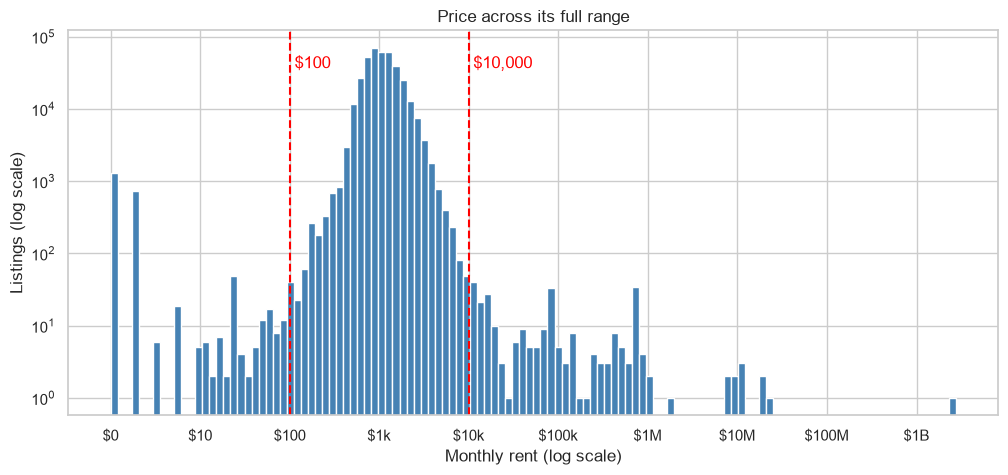

In [6]:
# 2.5 Full-range view on a log scale

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(np.log10(price + 1), bins=120, color="steelblue")
ax.set_yscale("log")

for limit in [100, 10_000]:
    ax.axvline(np.log10(limit + 1), color="red", linestyle="--")
    ax.text(np.log10(limit + 1) + 0.05, ax.get_ylim()[1] * 0.3, f"${limit:,}", color="red")

ax.set_xticks(range(10))
ax.set_xticklabels(["$0", "$10", "$100", "$1k", "$10k", "$100k", "$1M", "$10M", "$100M", "$1B"])
ax.set(xlabel="Monthly rent (log scale)", ylabel="Listings (log scale)",
       title="Price across its full range")
save_fig("02_price_full_range")
plt.show()

# Findings to note: the main body of rents, and any separate clusters far from it.

## 2.6 Choosing the plausibility rule

**What:** apply several candidate rules and compare how many rows each removes and how it changes the distribution.

**Why:** this makes the threshold an evidence-based decision rather than a guess, which is exactly what the viva will ask about. We want a rule that removes clear errors while losing as few genuine listings as possible.

**Is filtering on the target leakage?** No, as long as the rule is a **fixed domain rule** (a U.S. monthly rent below \$100 is not a real rent) and not something learned from the data, such as "remove the top 1%". Invalid labels are removed from both training and test data because they cannot be evaluated meaningfully. At prediction time the system never sees a price, so the rule doesn't affect how the deployed model is used.

In [7]:
# 2.6 Compare candidate rules

rules = [(0, np.inf), (1, np.inf), (100, 10_000), (200, 10_000), (100, 15_000), (100, 20_000)]

rows = []
for lo, hi in rules:
    kept = price[(price >= lo) & (price <= hi)]
    rows.append({
        "rule": f"${lo:,} to " + (f"${hi:,}" if np.isfinite(hi) else "no max"),
        "rows_kept": len(kept),
        "rows_removed": len(price) - len(kept),
        "removed_%": (len(price) - len(kept)) / len(price) * 100,
        "median": kept.median(),
        "mean": kept.mean(),
        "skew_raw": kept.skew(),
        "skew_log1p": np.log1p(kept).skew(),
    })

pd.DataFrame(rows).style.format({
    "rows_kept": "{:,}", "rows_removed": "{:,}", "removed_%": "{:.3f}%",
    "median": "${:,.0f}", "mean": "${:,.0f}", "skew_raw": "{:.2f}", "skew_log1p": "{:.2f}",
})

# Findings to note: how much the mean moves towards the median once errors are removed,
# and how few rows each rule costs.

,rule,rows_kept,rows_removed,removed_%,median,mean,skew_raw,skew_log1p
0,$0 to no max,"384,977",0,0.000%,"$1,036","$8,826",620.24,-5.14
1,$1 to no max,"383,670","1,307",0.340%,"$1,040","$8,856",619.19,-2.59
2,"$100 to $10,000","382,494","2,483",0.645%,"$1,040","$1,187",2.84,0.31
3,"$200 to $10,000","382,103","2,874",0.747%,"$1,041","$1,188",2.85,0.40
4,"$100 to $15,000","382,564","2,413",0.627%,"$1,040","$1,189",3.70,0.34
5,"$100 to $20,000","382,593","2,384",0.619%,"$1,040","$1,190",4.68,0.35


In [8]:
# 2.6 (cont.) Chosen rule: $100 to $10,000
#
# Why $100: $0 and $1 are placeholders ("call for price"); 2.4 shows they are real
#   apartments with no price entered. Only 2,214 rows (0.58%) are below $100.
# Why $10,000: above it, most listings are sale prices (e.g. manufactured homes "for sale"),
#   repeated nonsense values or typos. Some genuine luxury homes exist there, but only
#   269 rows (0.07%) are above $10,000 - too few for any model to learn from - and raising
#   the limit to $20,000 keeps just 99 more rows while raw skew rises from 2.84 to 4.68.
#   So the system is scoped to rents up to $10,000, stated as a limitation in the report.
#
# The values live in src/utils.py (PRICE_MIN, PRICE_MAX) so every later notebook uses the same rule.

valid = price.between(PRICE_MIN, PRICE_MAX)
p = price[valid]
print(f"Valid range ${PRICE_MIN:,} to ${PRICE_MAX:,}: keeps {valid.sum():,} rows, "
      f"removes {(~valid).sum():,} ({(~valid).mean() * 100:.2f}%)")

Valid range $100 to $10,000: keeps 382,494 rows, removes 2,483 (0.64%)


## 2.7 Shape of the valid prices: raw vs log

**What:** histograms of price and of `log1p(price)` for the valid rows, plus a Q-Q plot of the log values.

**Why:** even after removing errors, rents are right-skewed: most listings are cheap and a long tail is expensive. A skewed target causes two problems. Squared-error models chase the few expensive listings, and linear regression's errors become uneven. `log1p(price)` = log(1 + price) compresses the tail. A Q-Q plot compares the log values to a normal distribution: points close to the straight line mean the log transform worked.

Predictions made on the log scale are converted back to dollars with `expm1()`, the exact inverse.

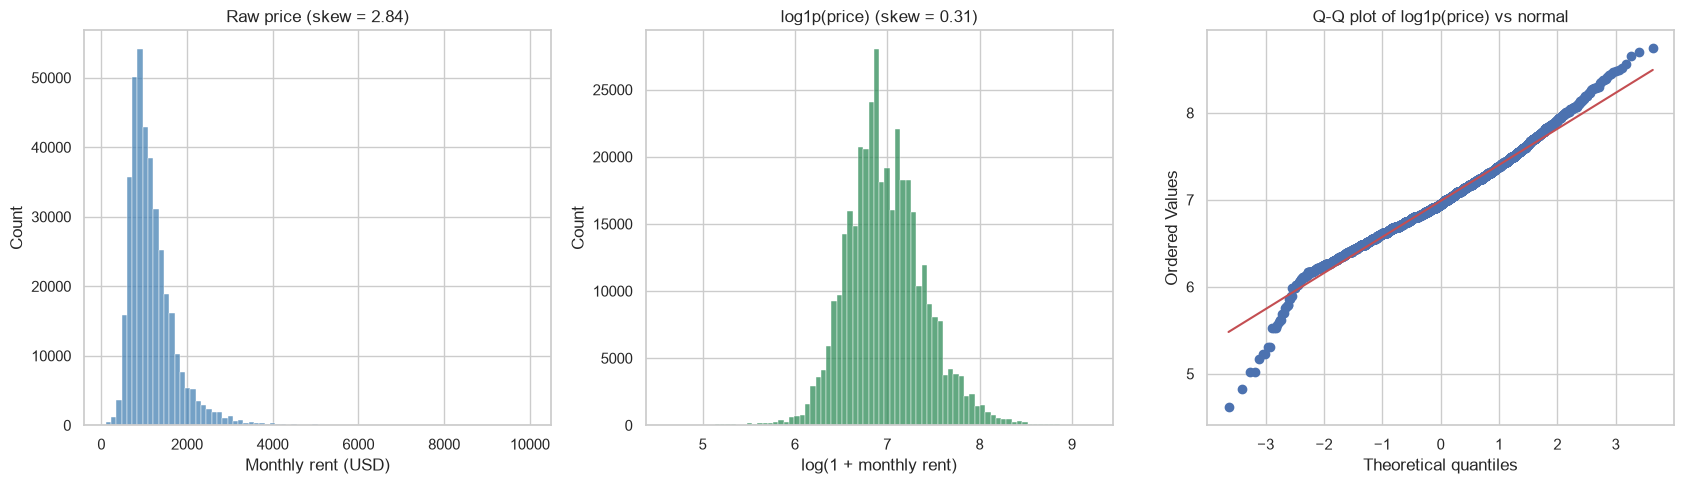

In [9]:
# 2.7 Raw vs log-transformed distribution (valid rows only)

log_p = np.log1p(p)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.histplot(p, bins=80, ax=axes[0], color="steelblue")
axes[0].set(title=f"Raw price (skew = {p.skew():.2f})", xlabel="Monthly rent (USD)")

sns.histplot(log_p, bins=80, ax=axes[1], color="seagreen")
axes[1].set(title=f"log1p(price) (skew = {log_p.skew():.2f})", xlabel="log(1 + monthly rent)")

qq_sample = log_p.sample(5_000, random_state=RANDOM_STATE)   # Q-Q plot needs a sample, not 380k points
stats.probplot(qq_sample, dist="norm", plot=axes[2])
axes[2].set(title="Q-Q plot of log1p(price) vs normal")

plt.tight_layout()
save_fig("02_price_raw_vs_log")
plt.show()

# Findings to note: skewness before and after, and whether the Q-Q points follow the line
# (small bends at the ends are normal for real data).

## 2.8 Price bands for a stratified split

**What:** split the valid log prices into 10 equal-sized bands (deciles) and show the dollar range of each.

**Why:** in Step 7 we split the data into training and test sets. A purely random split could, by chance, put too few expensive listings in the test set. **Stratifying** on these price bands makes sure both sets contain the same mix of cheap, typical and expensive rentals, so the test score is fair across the whole price range.

In [10]:
# 2.8 Log-price deciles for stratification

deciles = pd.qcut(log_p, q=10, duplicates="drop")
decile_table = deciles.value_counts().sort_index().rename("listings").to_frame()
decile_table["from_$"] = [np.expm1(iv.left) for iv in decile_table.index]
decile_table["to_$"] = [np.expm1(iv.right) for iv in decile_table.index]
decile_table.index = range(1, len(decile_table) + 1)
decile_table.index.name = "decile"

decile_table.style.format({"listings": "{:,}", "from_$": "${:,.0f}", "to_$": "${:,.0f}"})

# Findings to note: every band should have roughly 10% of listings.
# Uneven counts happen when many listings share the same round price (e.g. $1,000).

,listings,from_$,to_$
decile,,,
1,"38,338",$100,$655
2,"38,351",$655,$770
3,"38,158",$770,$855
4,"41,632",$855,$950
5,"34,889",$950,"$1,040"
6,"38,193","$1,040","$1,175"
7,"38,204","$1,175","$1,305"
8,"39,883","$1,305","$1,500"
9,"36,610","$1,500","$1,840"


## 2.9 Log the observations

`clear_obs("2")` first removes any earlier Step 2 entries, so re-running this cell after changing a threshold replaces the old numbers instead of keeping both versions.

In [11]:
# 2.9 Log the observations

clear_obs("2")

n_zero = int(price.eq(0).sum())
n_one = int(price.eq(1).sum())
n_low = int(price.lt(PRICE_MIN).sum())
n_high = int(price.gt(PRICE_MAX).sum())
n_removed = n_low + n_high

# Most repeated absurd value above the limit, and where it comes from
top_high = price[price > PRICE_MAX].value_counts()
rep_value, rep_count = top_high.index[0], int(top_high.iloc[0])
rep_rows = df.loc[price.eq(rep_value)]
rep_place = f"{rep_rows['region'].mode()[0]}, {rep_rows['state'].mode()[0].upper()}"

# Decile balance (2.8)
decile_share = deciles.value_counts(normalize=True) * 100

log_obs("2-Target",
        f"price is extremely right-skewed: mean ${price.mean():,.0f} vs median ${price.median():,.0f}; "
        f"max ${price.max():,.0f}",
        "2.1 summary statistics and extreme quantiles",
        "Describe rent with the median, not the mean; report robust metrics (MAE, median absolute error) alongside RMSE")

log_obs("2-Target",
        f"{n_zero:,} listings at $0 and {n_one:,} at $1 ({n_low:,} below ${PRICE_MIN} in total); "
        f"examples are real apartments with no price entered",
        "2.2 threshold counts, 2.3 repeated values, 2.4 example listings",
        f"Placeholders, not rents: remove rows with price < ${PRICE_MIN} before the train/test split")

log_obs("2-Target",
        f"{n_high:,} listings above ${PRICE_MAX:,}: a mix of genuine luxury homes (large houses in LA, "
        f"Seattle, SF Bay), sale prices of homes posted as rentals, and nonsense values",
        "2.2 threshold counts, 2.4 example listings, 2.5 full-range histogram",
        f"Remove rows with price > ${PRICE_MAX:,}; state in the report that the system is scoped to rents "
        f"up to ${PRICE_MAX:,} (too few luxury rows for a model to learn from)")

log_obs("2-Target",
        "Some listings are properties for SALE posted in the rental section "
        "(e.g. manufactured homes 'for sale' with a separate lot rent)",
        "2.3 repeated values (e.g. $78,500 x 25), 2.4 example descriptions",
        "In Step 5, search descriptions for sale wording, since cheaper sale listings may sit inside the valid range")

log_obs("2-Target",
        f"The same absurd price ${rep_value:,} appears {rep_count} times, all from one complex ({rep_place})",
        "2.3 repeated values, 2.4 example listings",
        "Evidence of one listing reposted many times; quantify duplicates in Step 4")

log_obs("2-Target",
        f"Plausibility rule ${PRICE_MIN}-${PRICE_MAX:,} removes {n_removed:,} rows ({n_removed / len(price) * 100:.2f}%)",
        "2.6 comparison of candidate rules",
        "Fixed domain rule (not learned from data), so applying it before the split does not cause leakage")

log_obs("2-Target",
        f"Log transform alone does not fix the target: log skew is {np.log1p(price).skew():.2f} before filtering "
        f"(pulled by $0/$1) vs {log_p.skew():.2f} after; raw skew of valid prices is {p.skew():.2f}",
        "2.6 comparison of candidate rules, 2.7 histograms",
        "Filter invalid prices first, then model log1p(price); convert predictions back with expm1")

log_obs("2-Target",
        "Q-Q plot: log prices follow a normal shape except a heavier lower tail (rents of roughly $100-$250)",
        "2.7 Q-Q plot",
        "Re-examine very low rents with price per sqft in Step 5 (possible rooms, shared units or weekly rates)")

log_obs("2-Target",
        f"Log-price deciles hold {decile_share.min():.1f}%-{decile_share.max():.1f}% of valid listings each; "
        f"unevenness comes from popular round prices (e.g. $950, $1,000)",
        "2.8 decile table, spiky log1p histogram in 2.7",
        "Stratify the train/test split on log-price deciles (Step 7)")

show_obs(2)

,step,observation,evidence,decision
0,2-Target,"price is extremely right-skewed: mean $8,826 v...",2.1 summary statistics and extreme quantiles,"Describe rent with the median, not the mean; r..."
1,2-Target,"1,307 listings at $0 and 731 at $1 (2,214 belo...","2.2 threshold counts, 2.3 repeated values, 2.4...","Placeholders, not rents: remove rows with pric..."
2,2-Target,"269 listings above $10,000: a mix of genuine l...","2.2 threshold counts, 2.4 example listings, 2....","Remove rows with price > $10,000; state in the..."
3,2-Target,Some listings are properties for SALE posted i...,"2.3 repeated values (e.g. $78,500 x 25), 2.4 e...","In Step 5, search descriptions for sale wordin..."
4,2-Target,"The same absurd price $679,710 appears 30 time...","2.3 repeated values, 2.4 example listings",Evidence of one listing reposted many times; q...
5,2-Target,"Plausibility rule $100-$10,000 removes 2,483 r...",2.6 comparison of candidate rules,"Fixed domain rule (not learned from data), so ..."
6,2-Target,Log transform alone does not fix the target: l...,"2.6 comparison of candidate rules, 2.7 histograms","Filter invalid prices first, then model log1p(..."
7,2-Target,Q-Q plot: log prices follow a normal shape exc...,2.7 Q-Q plot,Re-examine very low rents with price per sqft ...
8,2-Target,Log-price deciles hold 9.1%-10.9% of valid lis...,"2.8 decile table, spiky log1p histogram in 2.7",Stratify the train/test split on log-price dec...



## Step 2 – Summary of findings

| Finding | Evidence | Decision |
|---|---|---|
| Mean rent (\$8,826) is 8.5× the median (\$1,036) because of absurd values | 2.1 | Use the median; report MAE and median absolute error |
| 1,307 listings at \$0 and 731 at \$1; they are real apartments with no price entered | 2.3, 2.4 | Remove price < \$100 (placeholders, not rents) |
| 269 listings above \$10,000: luxury homes, sale prices and nonsense values (up to \$2.77 billion) | 2.2, 2.4, 2.5 | Remove price > \$10,000; system scoped to rents ≤ \$10,000 |
| Some listings are homes **for sale** posted as rentals (e.g. \$78,500 manufactured homes) | 2.3, 2.4 | Search descriptions for sale wording in Step 5 |
| \$679,710 appears 30 times, all from one apartment complex | 2.3, 2.4 | Evidence of reposting; quantify in Step 4 |
| The \$100–\$10,000 rule removes only 2,483 rows (0.64%) and brings the mean (\$1,187) close to the median | 2.6 | Adopt the rule; it is a fixed domain rule, so no leakage |
| Log skew is −5.14 before filtering but 0.31 after; raw skew of valid prices is 2.84 | 2.6, 2.7 | Filter first, then model `log1p(price)` |
| Q-Q plot is close to normal except a heavier lower tail (≈ \$100–\$250) | 2.7 | Re-check low rents with price per sqft in Step 5 |
| Log-price deciles hold 9.1%–10.8% of listings each | 2.8 | Stratify the split on these deciles in Step 7 |

**Why \$10,000 and not higher?** Some listings above \$10,000 are genuine (e.g. a 4,000 sqft house near Mulholland Drive in Los Angeles). But there are only 269 of them, mixed with sale prices and errors. Raising the limit to \$20,000 would keep just 99 more rows while the raw skewness rises from 2.84 to 4.68. A model cannot learn luxury pricing from so few examples, so we scope the system to rents up to \$10,000 and state this as a limitation.
